# Import the stuff needed

In [113]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [114]:
# Set the overall style (e.g., 'whitegrid' for clean background with grid lines)
sns.set_theme(style='whitegrid', palette='muted')

# Scale the fonts and elements up so they are readable in a presentation
sns.set_context('talk')  # Options: 'paper', 'notebook', 'talk', 'poster'

## **Phase 1: Data Integration**

**Create a Unified Identifier**: Map customer_support_tickets.csv to customers.csv using customer_email and customer_name to append customer_id to your ticket data.

**Merge Usage Data**: Join product_usage.csv to this combined dataset using customer_id and matching product to product_purchased.


In [115]:

customers = pd.read_csv(
    "customers.csv"
)

tickets = pd.read_csv(
    "customer_support_tickets.csv"
)

# Merge the datasets
customers_and_tickets = tickets.merge(
    customers,
    how="left",
    on=['Customer Email', 'Customer Name', 'Customer Age', 'Customer Gender'], 
)

# Prdouct usage
customers_and_tickets_loom = customers_and_tickets[customers_and_tickets["Product Purchased"] == "Loom"]

products = pd.read_csv("product_usage.csv")
products_loom = products[products["Product"] == "Loom"]

customers_and_tickets_products = customers_and_tickets_loom.merge(
    products_loom, 
    how="left",
    left_on="Product Purchased",
    right_on="Product"
)

customers_and_tickets_products = customers_and_tickets_products.drop(columns=["Customer Age", "Customer Gender"])


## **Phase 2: Feature Engineering**

**Define Explicit Churn**: Create a binary churn_request variable. Flag this as 1 if ticket_type or ticket_subject contains terms like "Cancellation", "Cancel", or "Refund".


In [116]:
customers_and_tickets_products["Explicit Churn"] = customers_and_tickets_products["Ticket Type"].isin(["Cancellation request", "Refund request"]) | customers_and_tickets_products["Ticket Subject"].isin(["Cancellation request", "Refund request"])

**Define Implicit Churn (Usage Drop-off)**: Calculate month-over-month changes in active_days and sessions from product_usage.csv. Flag users whose activity drops to zero shortly after submitting a ticket.

In [117]:
import datetime as dt

In [118]:
# Ensure date columns are proper datetime objects
products_loom['Month'] = pd.to_datetime(products_loom['Month'])
customers_and_tickets_loom['First Response Time'] = pd.to_datetime(customers_and_tickets_loom['First Response Time'], dayfirst=True)

# 3. Calculate Month-over-Month changes in usage
# Sort to ensure chronological order for the shift() function
products_loom = products_loom.sort_values(by=['Customer ID', 'Product', 'Month'])

# Group by customer and product, then shift to get previous month's data
products_loom['prev_active_days'] = products_loom.groupby(['Customer ID', 'Product'])['Active Days'].shift(1)
products_loom['prev_sessions'] = products_loom.groupby(['Customer ID', 'Product'])['Sessions'].shift(1)

# Calculate absolute MoM change
products_loom['mom_active_days_change'] = products_loom['Active Days'] - products_loom['prev_active_days']
products_loom['mom_sessions_change'] = products_loom['Sessions'] - products_loom['prev_sessions']

# 4. Define Implicit Churn (Usage Drop-off)
# User had activity last month, but 0 activity this month
products_loom['dropped_to_zero'] = (products_loom['Active Days'] == 1) & (products_loom['prev_active_days'] > 1)

# Extract just the churn events to cross-reference with tickets
churn_events = products_loom[products_loom['dropped_to_zero']][['Customer ID', 'Product', 'Month']]
churn_events = churn_events.rename(columns={'Month': 'churn_month'})

# 5. Flag users whose activity drops to zero shortly after a ticket 
# # Be careful here
# Merge tickets with churn events
ticket_churn_analysis = customers_and_tickets_loom.merge(churn_events, on='Customer ID', how='inner')

# Calculate days between the first support response and the month they churned
# Note: churn_month is usually the 1st of the month, so this is an approximation
ticket_churn_analysis['days_to_churn'] = (ticket_churn_analysis['churn_month'] - ticket_churn_analysis['First Response Time']).dt.days

# Define "shortly after" as churning within 60 days of the ticket
ticket_churn_analysis['churned_shortly_after_ticket'] = ticket_churn_analysis['days_to_churn'] < 0

# Get the final list of Customer IDs who meet the criteria
at_risk_users = ticket_churn_analysis[ticket_churn_analysis['churned_shortly_after_ticket']]['Customer ID'].unique()

print(f"Identified {len(at_risk_users)} users who dropped off shortly after a ticket.")

Identified 111 users who dropped off shortly after a ticket.


In [119]:
at_risk_users

<StringArray>
['CUST07659', 'CUST04338', 'CUST00671', 'CUST00349', 'CUST06092', 'CUST08306',
 'CUST01127', 'CUST08268', 'CUST04643', 'CUST05158',
 ...
 'CUST02178', 'CUST06425', 'CUST02640', 'CUST03135', 'CUST08013', 'CUST07263',
 'CUST01469', 'CUST05497', 'CUST00965', 'CUST03621']
Length: 111, dtype: str

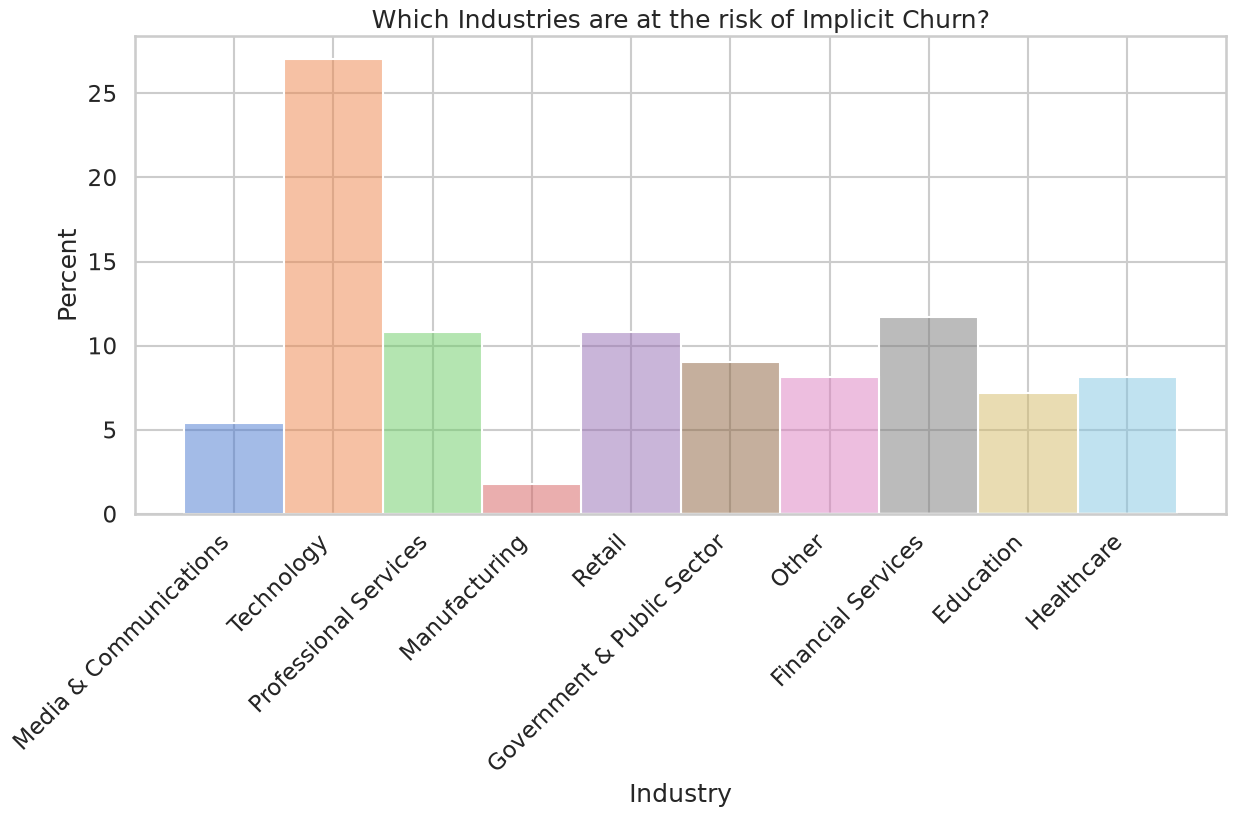

In [150]:
all_customers = pd.read_csv("customers.csv")
at_risk_customers = all_customers[all_customers["Customer ID"].isin(at_risk_users)]

plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=at_risk_customers,
    x="Industry",
    hue="Industry",
    stat="percent",
    common_norm=True,
    legend=False
).set_title("Which Industries are at the risk of Implicit Churn?")

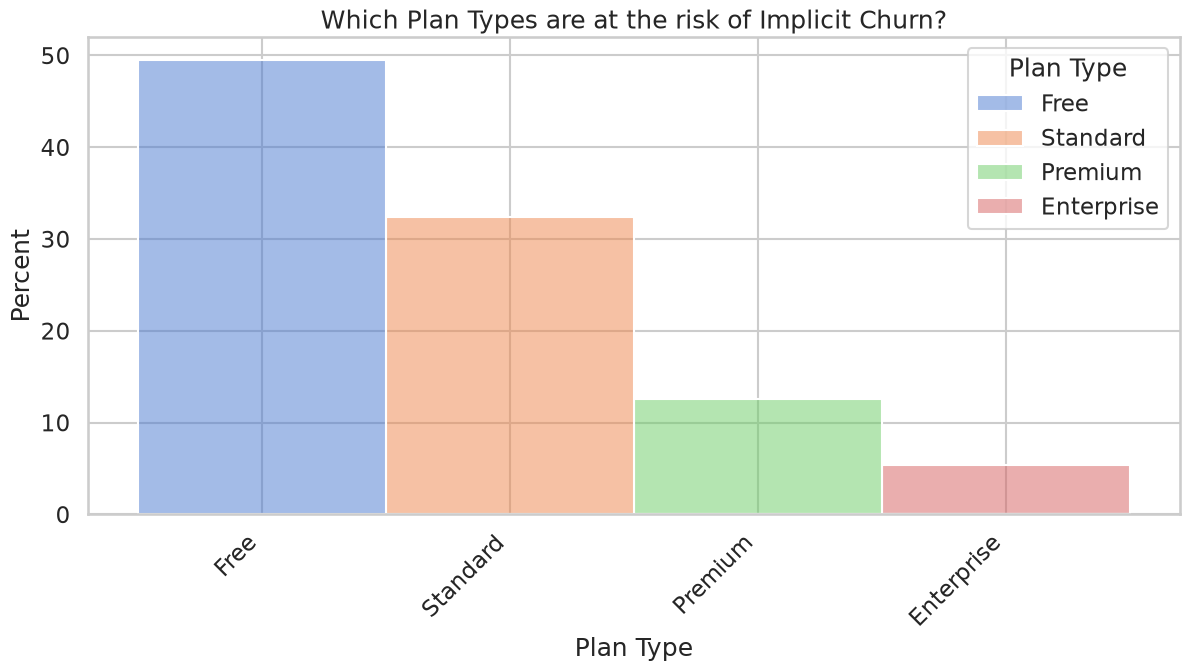

In [149]:
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=at_risk_customers,
    x="Plan Type",
    hue="Plan Type",
    stat="percent",
    common_norm=True,
).set_title("Which Plan Types are at the risk of Implicit Churn?")

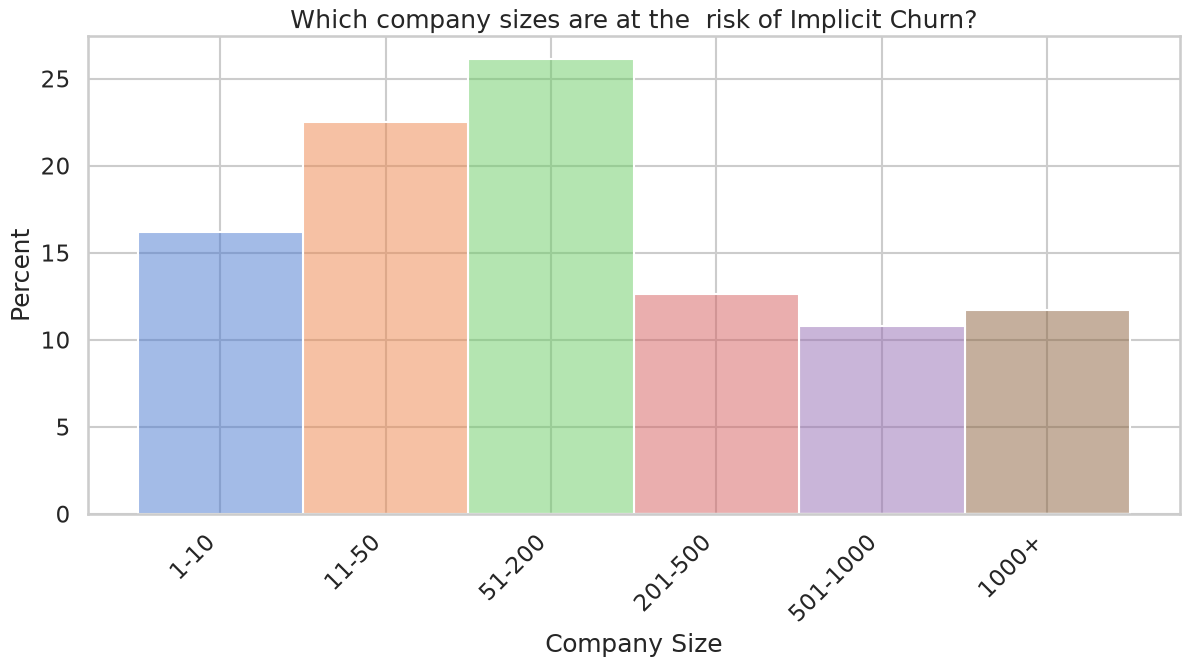

In [154]:
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# 1. Define the correct chronological/logical order
size_order = ['1-10', '11-50', '51-200', '201-500', '501-1000', '1000+']

# 2. Convert the column to a categorical type with that specific order
at_risk_customers['Company Size'] = pd.Categorical(at_risk_customers['Company Size'], categories=size_order, ordered=True)

a = sns.histplot(
    data=at_risk_customers,
    x="Company Size",
    hue="Company Size",
    stat="percent",
    common_norm=True,
    hue_order=["1-10", "11-50", "51-200", "201-500", "501-1000", "1000+"],
    legend=False
).set_title("Which company sizes are at the  risk of Implicit Churn?")

In [123]:
len(customers_and_tickets_loom["Customer Name"].unique())

1615

**Isolate CX Metrics**: Extract customer_satisfaction_rating, time_to_resolution, and first_response_time as your primary independent variables (drivers of experience).

## **Phase 3: Exploratory Data Analysis (EDA)**

**CSAT vs. Cancellation**: Plot the distribution of customer_satisfaction_rating for customers who submitted cancellation/refund requests versus those who did not.


Text(0.5, 1.0, 'CSAT Scores across Explicit Churn users')

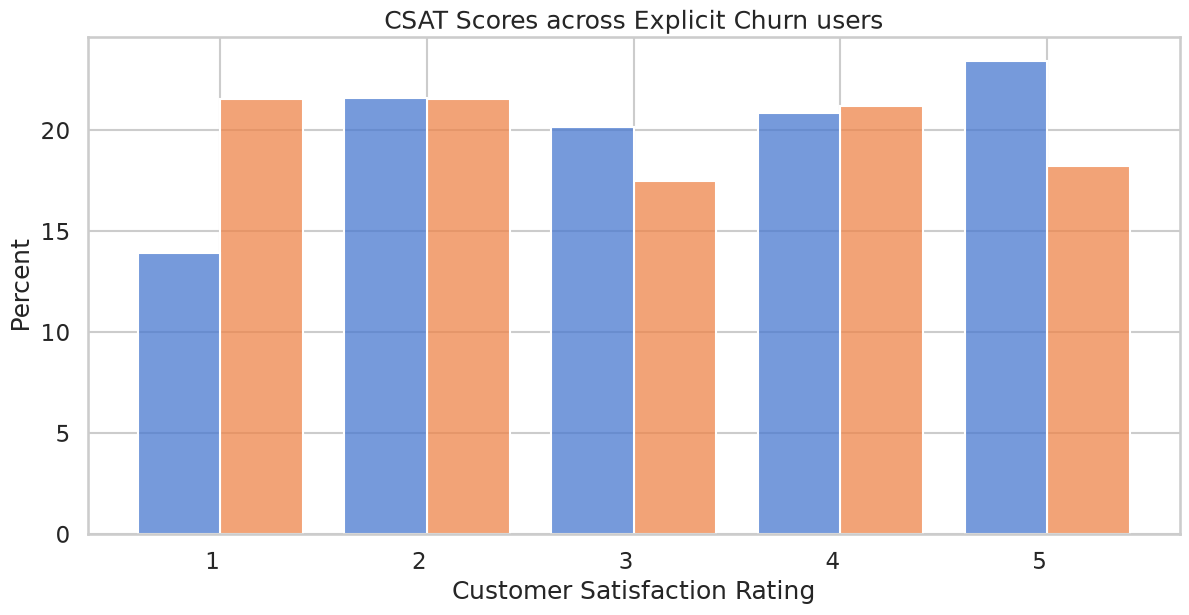

In [160]:
tickets_loom = pd.read_csv("customer_support_tickets.csv")
tickets_loom = tickets_loom[tickets_loom["Product Purchased"] == "Loom"]

# Get the cancelled users
cancelled_users = tickets_loom[tickets_loom["Ticket Type"].isin(["Cancellation request", "Refund request"])]
cancelled_users = cancelled_users[cancelled_users["Ticket Status"] == "Closed"]

# Get the non-cancelled users
non_cancelled_users = tickets_loom[~tickets_loom["Ticket Type"].isin(["Cancellation request", "Refund request"])]
non_cancelled_users = non_cancelled_users[non_cancelled_users["Ticket Status"] == "Closed"]

# Explicit Churn Dataset
tickets_loom["Explicit Churn"] = tickets_loom["Ticket Type"].isin(["Cancellation request", "Refund request"]) | tickets_loom["Ticket Subject"].isin(["Cancellation request", "Refund request"])
plt.figure(figsize=(12, 6))
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=tickets_loom,
    x="Customer Satisfaction Rating",
    hue="Explicit Churn",
    discrete=True,
    shrink=0.8,
    multiple="dodge",
    stat="percent",
    common_norm=False,
    legend=False
).set_xticks([1, 2, 3, 4, 5])
plt.title("CSAT Scores across Explicit Churn users")


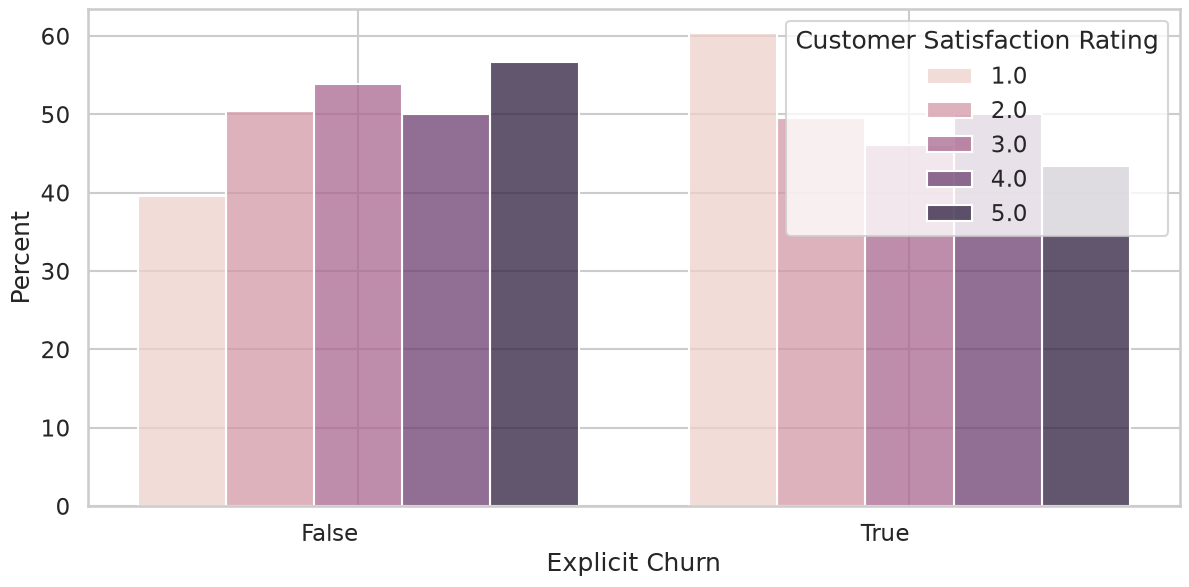

In [167]:
tickets_loom['Explicit Churn'] = tickets_loom['Explicit Churn'].astype(str)
plt.figure(figsize=(12, 6))
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=tickets_loom,
    hue="Customer Satisfaction Rating",
    x="Explicit Churn",
    multiple="dodge",
    shrink=0.8,
    stat="percent",
    common_norm=False,
    legend=True
)


In [126]:
tickets_loom["Customer Satisfaction Rating"].value_counts().reset_index().sort_values("Customer Satisfaction Rating")

,Customer Satisfaction Rating,count
4,1.0,96
0,2.0,117
3,3.0,102
1,4.0,114
2,5.0,113


In [127]:
cancelled_users["Customer Satisfaction Rating"].value_counts().reset_index().sort_values("Customer Satisfaction Rating")

,Customer Satisfaction Rating,count
0,1.0,53
1,2.0,50
4,3.0,42
2,4.0,48
3,5.0,43


In [128]:
non_cancelled_users["Customer Satisfaction Rating"].value_counts().reset_index().sort_values("Customer Satisfaction Rating")

,Customer Satisfaction Rating,count
4,1.0,43
1,2.0,67
3,3.0,60
2,4.0,66
0,5.0,70


**Timeline Analysis**: Calculate the churn rate across the months.


In [129]:
num_requests_df = tickets_loom[["Customer Email"]].value_counts().reset_index(name="num_requests").sort_values("num_requests", ascending=False)
num_requests_df = num_requests_df[num_requests_df["num_requests"] > 1]
num_requests_df

,Customer Email,num_requests
0,ghernandez@example.com,2
1,bsmith@example.com,2


In [130]:
tickets_num_requests = tickets_loom
tickets_num_requests['num_requests'] = tickets_num_requests.groupby(["Customer Email", "Product Purchased"])['Ticket Type'].transform(lambda x: x.count())

In [131]:
# Customers
customers = pd.read_csv("customers.csv")
tickets_loom = pd.read_csv("customer_support_tickets.csv")
tickets_loom = tickets_loom[tickets_loom["Product Purchased"] == "Loom"]
tickets_loom["Explicit Churn"] = tickets_loom["Ticket Type"].isin(["Cancellation request", "Refund request"])

# Tickets + Customers
churned_users = tickets_loom[tickets_loom["Explicit Churn"]]
tickets_loom_customers = pd.merge(
    tickets_loom, 
    customers, 
    on=['Customer Email', 'Customer Name', 'Customer Age', 'Customer Gender'], 
    how='left'
)

# Get the cancelled users
cancelled_loom_users = tickets_loom_customers[tickets_loom_customers["Explicit Churn"]]
cancelled_loom_users_columns = cancelled_loom_users.columns

# Get the products
products_loom = pd.read_csv("product_usage.csv")
products_loom = products_loom[products_loom["Product"] == "Loom"]

# Get the cancelled users with First Response Time as NAN
cancelled_loom_users_with_na = cancelled_loom_users[cancelled_loom_users["First Response Time"].isna()]
print(len(cancelled_loom_users_with_na))

# We will fill up 221 rows of NAN of First Response Time with product last_used date
# Merge with Product
cancelled_loom_users_with_na_products = pd.merge(
    cancelled_loom_users_with_na,
    products_loom,
    how="left",
    on="Customer ID"
)

# Set the  Reponse time as the the Month
cancelled_loom_users_with_na_products["First Response Time"] = cancelled_loom_users_with_na_products["Month"]

# Convert to datetime if it's currently a string
cancelled_loom_users_with_na_products['Month'] = pd.to_datetime(cancelled_loom_users_with_na_products['Month'])
cancelled_loom_users_with_na_products['First Response Time'] = pd.to_datetime(cancelled_loom_users_with_na_products['First Response Time'])

# Extract the rows with the max date per customer
latest_rows = cancelled_loom_users_with_na_products.loc[cancelled_loom_users_with_na_products.groupby('Customer ID')['First Response Time'].idxmax()]

# All cancelled loom_users
cancelled_loom_users_without_na = cancelled_loom_users[~cancelled_loom_users["First Response Time"].isna()]
all_cancelled_loom_users = pd.concat(
    [cancelled_loom_users_without_na, latest_rows[cancelled_loom_users_columns]],
    axis=0
)

221


**Segment by Value**: Group cancellation rates by plan_type and company_size to identify which high-value cohorts are most sensitive to poor support experiences.

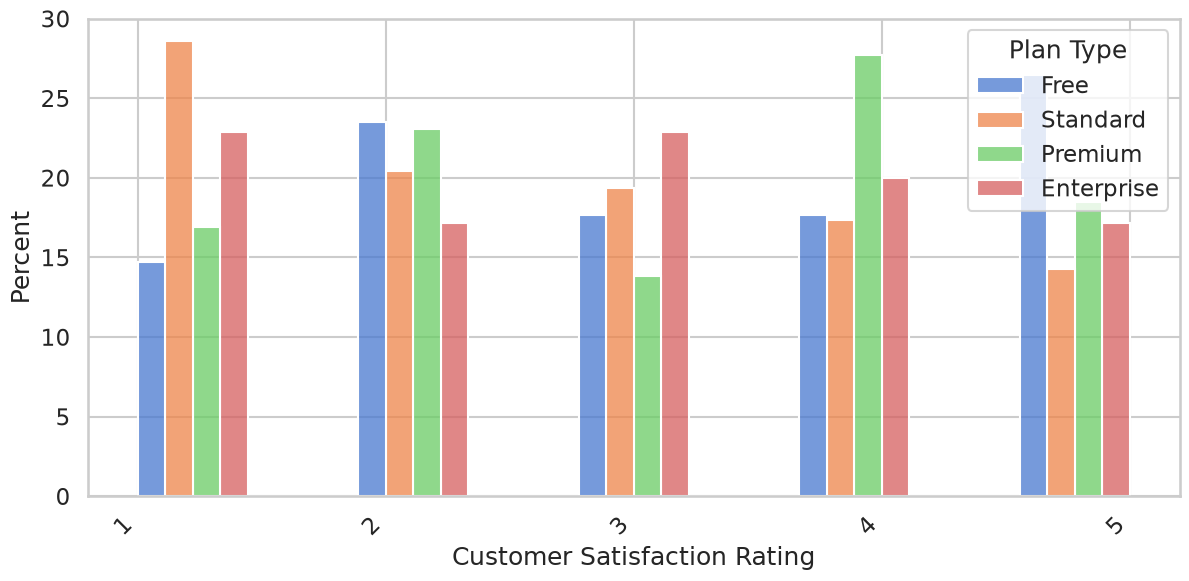

In [132]:
cancelled_tickets_loom_customers = tickets_loom_customers[tickets_loom_customers["Explicit Churn"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=cancelled_tickets_loom_customers,
    x="Customer Satisfaction Rating",
    hue="Plan Type",
    multiple="dodge",
    stat="percent",
    common_norm=False,
).set_xticks([1, 2, 3, 4, 5])

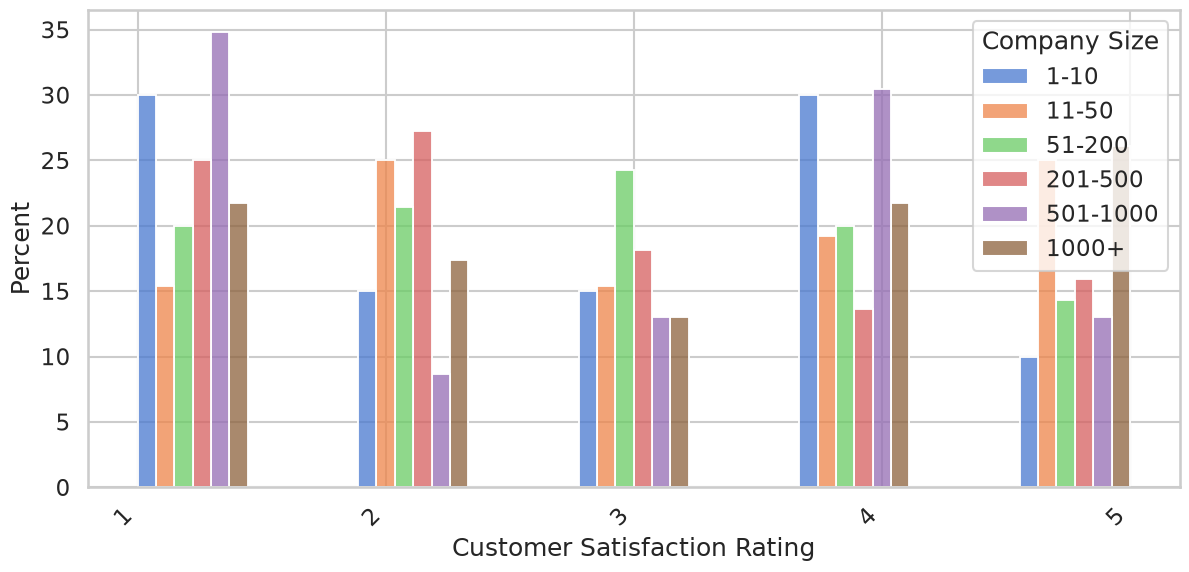

In [133]:
cancelled_tickets_loom_customers = tickets_loom_customers[tickets_loom_customers["Explicit Churn"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=cancelled_tickets_loom_customers,
    x="Customer Satisfaction Rating",
    hue="Company Size",
    multiple="dodge",
    stat="percent",
    common_norm=False,
    hue_order=["1-10", "11-50", "51-200", "201-500", "501-1000", "1000+"]
).set_xticks([1, 2, 3, 4, 5])

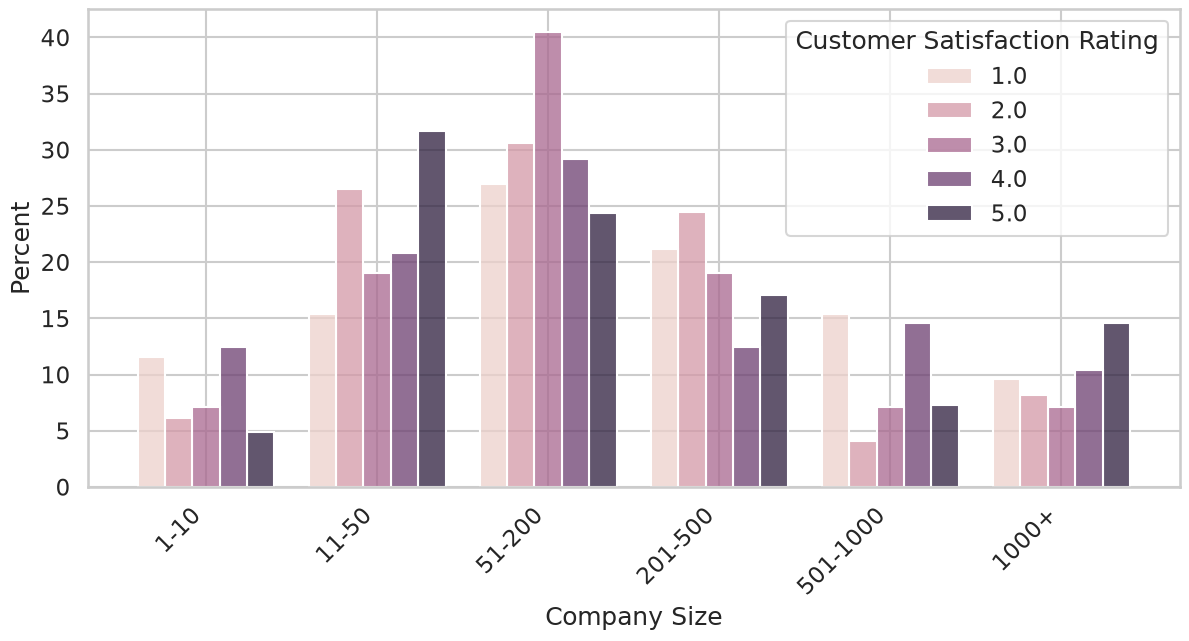

In [171]:
cancelled_tickets_loom_customers = tickets_loom_customers[tickets_loom_customers["Explicit Churn"]]

# 1. Define the correct chronological/logical order
size_order = ['1-10', '11-50', '51-200', '201-500', '501-1000', '1000+']

# 2. Convert the column to a categorical type with that specific order
cancelled_tickets_loom_customers['Company Size'] = pd.Categorical(cancelled_tickets_loom_customers['Company Size'], categories=size_order, ordered=True)

plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=cancelled_tickets_loom_customers,
    hue="Customer Satisfaction Rating",
    x="Company Size",
    multiple="dodge",
    stat="percent",
    shrink=0.8,
    discrete=True,
    common_norm=False,
    hue_order=[1, 2, 3, 4, 5]
).set_xticks(["1-10", "11-50", "51-200", "201-500", "501-1000", "1000+"])

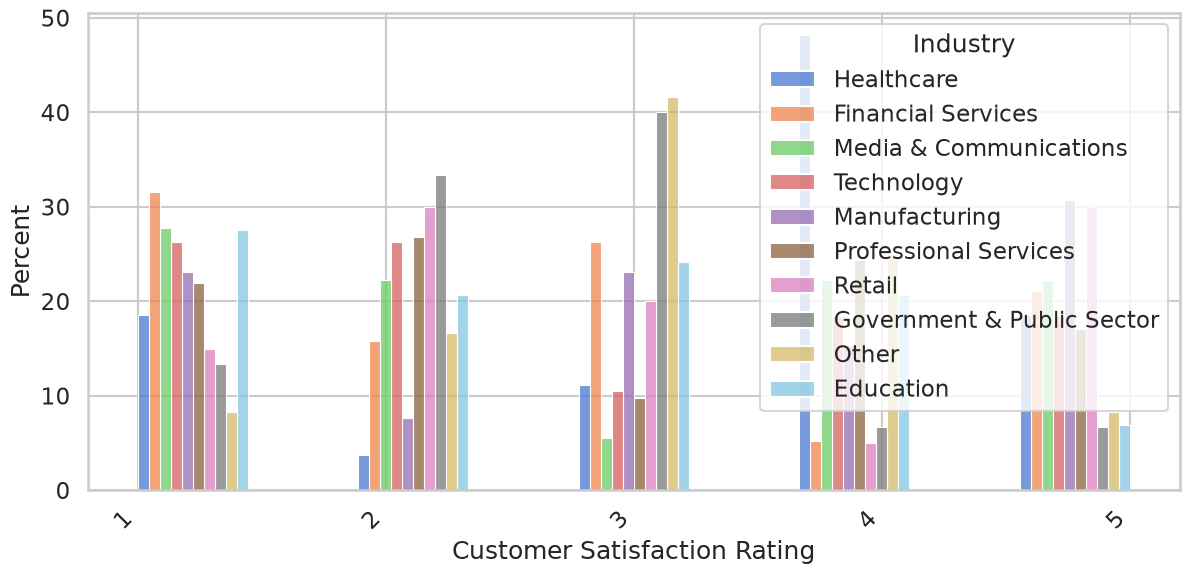

In [134]:
cancelled_tickets_loom_customers = tickets_loom_customers[tickets_loom_customers["Explicit Churn"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
a = sns.histplot(
    data=cancelled_tickets_loom_customers,
    x="Customer Satisfaction Rating",
    hue="Industry",
    multiple="dodge",
    stat="percent",
    common_norm=False,
).set_xticks([1, 2, 3, 4, 5])

## **Phase 4: Statistical Analysis & Predictive Modeling**

**Correlation Matrix**: Measure the statistical correlation between continuous CX variables (resolution time, CSAT) and usage metrics (active_days, product_actions).

**Logistic Regression**: Build a classification model to predict churn_request (0 or 1). Use customer_satisfaction_rating, ticket_priority, time_to_resolution, and plan_type as predictors to determine which CX factor has the heaviest statistical weight on churn probability.

**Decision Trees**: Use a tree-based model to find explicit breakpoints (e.g., "Customers with a CSAT below 3 and a resolution time over 48 hours have an 80% higher likelihood of requesting a refund").

In [135]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [136]:
tickets_loom.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Explicit Churn
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0,False
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Loom,28-07-2020,Cancellation request,Payment issue,Open,NaN,Low,Social media,NaN,NaN,NaN,True
9,10,William Dawson,clopez@example.com,27,Male,Loom,06-03-2020,Refund request,Payment issue,Pending Customer Response,NaN,Critical,Phone,01-06-2023 09:25,NaN,NaN,True
14,15,Amy Hill,medinasteven@example.net,48,Female,Loom,29-02-2020,Billing inquiry,Product setup,Closed,Officer moment world sing parent available.,High,Chat,01-06-2023 06:22,31-05-2023 23:08,4.0,False
20,21,Suzanne Holmes,rogermcgrath@example.net,28,Other,Loom,31-05-2021,Refund request,Payment issue,Pending Customer Response,NaN,High,Chat,01-06-2023 05:08,NaN,NaN,True


In [137]:
tickets_loom["First Response Time"] = pd.to_datetime(tickets_loom["First Response Time"], dayfirst=True)
tickets_loom["Time to Resolution"] = pd.to_datetime(tickets_loom["Time to Resolution"], dayfirst=True)
tickets_loom["Total Resolution Time"] = tickets_loom["Time to Resolution"] - tickets_loom["First Response Time"]
tickets_loom = tickets_loom[tickets_loom["Ticket Status"] == "Closed"]

In [138]:
# Impute by the Ticket Subject
ticket_subjects = tickets_loom["Ticket Subject"].value_counts().reset_index()

In [139]:
df_arr = []
tickets_loom_2 = tickets_loom
ticket_subjects = ticket_subjects["Ticket Subject"]

# Iterate over each ticket subject
    # Fill the NAs with the mean
for ticket_subject in ticket_subjects:
    current = tickets_loom_2[tickets_loom_2["Ticket Subject"] == str(ticket_subject)]
    current["Total Resolution Time"] = current["Total Resolution Time"].fillna(current["Total Resolution Time"].mean())
    current = current[current["Total Resolution Time"] >= pd.Timedelta(0)]
    current["Customer Satisfaction Rating"] = current["Customer Satisfaction Rating"].fillna(current["Customer Satisfaction Rating"].mean())

    df_arr.append(current)

tickets_loom_3 = pd.concat(df_arr, axis=0)
tickets_loom_3.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Explicit Churn,Total Resolution Time
108,109,Justin Martin,mreeves@example.com,33,Male,Loom,08-01-2020,Technical issue,Product setup,Closed,Feeling end role stage.,Critical,Chat,2023-06-01 02:55:00,2023-06-01 08:15:00,4.0,False,0 days 05:20:00
161,162,William Huerta,eortega@example.org,29,Female,Loom,06-01-2020,Refund request,Product setup,Closed,Idea tax writer everybody media.,High,Phone,2023-06-01 03:19:00,2023-06-01 15:58:00,3.0,True,0 days 12:39:00
164,165,Rebecca Patton,ballwilliam@example.com,24,Male,Loom,21-05-2021,Billing inquiry,Product setup,Closed,Represent wait idea guess five case.,Low,Social media,2023-06-01 19:39:00,2023-06-01 21:26:00,5.0,False,0 days 01:47:00
170,171,Angel Saunders,brandon58@example.com,44,Female,Loom,24-12-2021,Billing inquiry,Product setup,Closed,Believe spend others newspaper ability visit.,Low,Social media,2023-06-01 15:42:00,2023-06-01 18:36:00,4.0,False,0 days 02:54:00
250,251,Zachary Weiss,cindy89@example.org,19,Female,Loom,27-07-2021,Technical issue,Product setup,Closed,Heavy old particular something.,Critical,Phone,2023-06-01 03:15:00,2023-06-01 08:04:00,2.0,False,0 days 04:49:00


<Axes: xlabel='Total Resolution Time', ylabel='Customer Satisfaction Rating'>

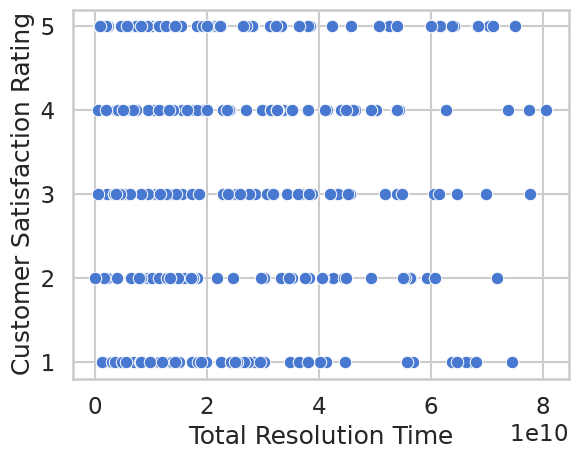

In [140]:
sns.scatterplot(
    data=tickets_loom_3,
    x="Total Resolution Time",
    y="Customer Satisfaction Rating"
)

In [141]:
product_setup = tickets_loom[tickets_loom["Ticket Subject"] == "Product setup"]
product_setup["Total Resolution Time"] = product_setup["Total Resolution Time"].fillna(product_setup["Total Resolution Time"].mean())

product_compatability = tickets_loom[tickets_loom["Ticket Subject"] == "Product compatability"]
product_compatability["Total Resolution Time"] = product_compatability["Total Resolution Time"].fillna(product_compatability["Total Resolution Time"].mean())



In [142]:
len(tickets_loom)

542

In [143]:
tickets_loom["Total Resolution Time"]

3      -1 days +18:28:00
14     -1 days +16:46:00
38     -1 days +03:08:00
44     -1 days +21:21:00
53       0 days 09:46:00
              ...       
8411     0 days 02:17:00
8414     0 days 02:11:00
8426     0 days 07:10:00
8430     0 days 04:13:00
8455   -1 days +16:43:00
Name: Total Resolution Time, Length: 542, dtype: timedelta64[us]

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Merge datasets to bring 'plan_type' into the tickets dataframe
tickets = tickets_loom_3
customers = pd.read_csv('customers.csv')
df = tickets.merge(customers[['Customer Email', 'Plan Type']], on='Customer Email', how='left')

# 2. Derive Target and Calculate Duration
# Assuming 'churn_request' is flagged within the 'ticket_subject' or 'resolution'
df['churn_request'] = df['Explicit Churn'].apply(lambda x: 1 if x == True else 0)

# Calculate resolution duration in hours
df['resolution_hours'] = df["Total Resolution Time"].dt.total_seconds() / 3600

# Drop rows with missing essential data for the model
df = df.dropna(subset=['Customer Satisfaction Rating', 'resolution_hours', 'Ticket Priority', 'Plan Type'])

# 3. Prepare Predictors (X) and Target (y)
X = df[['Customer Satisfaction Rating', 'resolution_hours', 'Ticket Priority', 'Plan Type']]

# One-hot encode categorical variables (priority and plan_type)
X = pd.get_dummies(X, columns=['Ticket Priority', 'Plan Type'], drop_first=True)
y = df['churn_request']

# 4. Standardize Features for Accurate Coefficient Comparison
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 5. Train Model
model = LogisticRegression(random_state=42)
model.fit(X_scaled, y)

# 6. Extract Statistical Weights
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Log-Odds Coefficient': model.coef_[0],
    'Absolute Weight': np.abs(model.coef_[0])
}).sort_values(by='Absolute Weight', ascending=False)

print(coefficients)


                        Feature  Log-Odds Coefficient  Absolute Weight
1              resolution_hours              0.220804         0.220804
5                Plan Type_Free             -0.175992         0.175992
0  Customer Satisfaction Rating             -0.171451         0.171451
4        Ticket Priority_Medium              0.086948         0.086948
6             Plan Type_Premium              0.070447         0.070447
7            Plan Type_Standard             -0.042692         0.042692
2          Ticket Priority_High             -0.029113         0.029113
3           Ticket Priority_Low              0.000990         0.000990
